# STEP 1 : Load Dataset and Examine its Structure

In [4]:
# STEP 1 : Load Dataset and Examine its Structure


# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("C:/Users/PMLS/OneDrive/Desktop/ITSimplera Internship/Steel_industry_data.csv")

# Display first 5 rows
print("First Five Rows:")
print(df.head())

# Display last 5 rows
print("\nLast Five Rows:")
print(df.tail())

# Dataset dimensions
print("\nDataset Shape:")
print(df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Information about dataset
print("\nDataset Information:")
print(df.info())

# Summary statistics
print("\nStatistical Summary:")
print(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate records
print("\nDuplicate Rows:")
print(df.duplicated().sum())

First Five Rows:
               date  Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0  01/01/2018 00:15       3.17                                  2.95   
1  01/01/2018 00:30       4.00                                  4.46   
2  01/01/2018 00:45       3.24                                  3.28   
3  01/01/2018 01:00       3.31                                  3.56   
4  01/01/2018 01:15       3.82                                  4.50   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   
3                                   0.0        0.0   
4                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         73.21                         100.0   900   
1                         66.77                         100.0  1800   
2           

# STEP 2 : Datetime Conversion and Feature Engineering

In [ ]:
# STEP 2 : Datetime Conversion and Feature Engineering


# Convert date column into datetime format
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Extract hour of day
df['Hour'] = df['date'].dt.hour

# Extract day of week (0 = Monday)
df['Day_Number'] = df['date'].dt.dayofweek

# Extract month
df['Month'] = df['date'].dt.month

# Create Weekday/Weekend feature
df['Day_Type'] = np.where(df['Day_Number'] < 5,
                          'Weekday',
                          'Weekend')

# Display new columns
print(df[['date','Hour','Day_Number','Month','Day_Type']].head())

                 date  Hour  Day_Number  Month Day_Type
0 2018-01-01 00:15:00     0           0      1  Weekday
1 2018-01-01 00:30:00     0           0      1  Weekday
2 2018-01-01 00:45:00     0           0      1  Weekday
3 2018-01-01 01:00:00     1           0      1  Weekday
4 2018-01-01 01:15:00     1           0      1  Weekday


# STEP 3 : Create Power Factor Ratio Feature

In [6]:
# STEP 3 : Create Power Factor Ratio Feature


# Create a new feature by dividing leading power factor
# by lagging power factor

df['Power_Factor_Ratio'] = (
    df['Leading_Current_Power_Factor'] /
    df['Lagging_Current_Power_Factor']
)

# Display first five rows of the new feature
print(df[['Leading_Current_Power_Factor',
          'Lagging_Current_Power_Factor',
          'Power_Factor_Ratio']].head())

   Leading_Current_Power_Factor  Lagging_Current_Power_Factor  \
0                         100.0                         73.21   
1                         100.0                         66.77   
2                         100.0                         70.28   
3                         100.0                         68.09   
4                         100.0                         64.72   

   Power_Factor_Ratio  
0            1.365934  
1            1.497679  
2            1.422880  
3            1.468644  
4            1.545117  


# STEP 4 : Create High Usage Feature

In [ ]:
# STEP 4 : Create High Usage Feature


# Calculate the 75th percentile of Usage_kWh
usage_threshold = df['Usage_kWh'].quantile(0.75)

print("75th Percentile:", usage_threshold)

# Create binary feature
df['High_Usage'] = np.where(
    df['Usage_kWh'] > usage_threshold,
    1,
    0
)

# Count values
print("\nHigh Usage Counts:")
print(df['High_Usage'].value_counts())

# Display first few rows
print(df[['Usage_kWh', 'High_Usage']].head())

75th Percentile: 51.2375

High Usage Counts:
High_Usage
0    26280
1     8760
Name: count, dtype: int64
   Usage_kWh  High_Usage
0       3.17           0
1       4.00           0
2       3.24           0
3       3.31           0
4       3.82           0


# STEP 5 : Detect Outliers using IQR Method

Q1 : 3.2
Q3 : 51.2375
IQR : 48.037499999999994

Lower Limit : -68.85624999999999
Upper Limit : 123.29374999999999

Number of Outliers : 328

First Five Outliers:
                   date  Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
140 2018-01-02 11:15:00     128.52                                 70.85   
141 2018-01-02 11:30:00     144.47                                 78.48   
143 2018-01-02 12:00:00     123.30                                 66.06   
150 2018-01-02 13:45:00     124.45                                 49.79   
153 2018-01-02 14:30:00     129.10                                 53.50   

     Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
140                                   0.0        0.0   
141                                   0.0        0.0   
143                                   0.0        0.0   
150                                   0.0        0.0   
153                                   0.0        0.0   

     Lagging_Current_Power_Factor  Leading_C

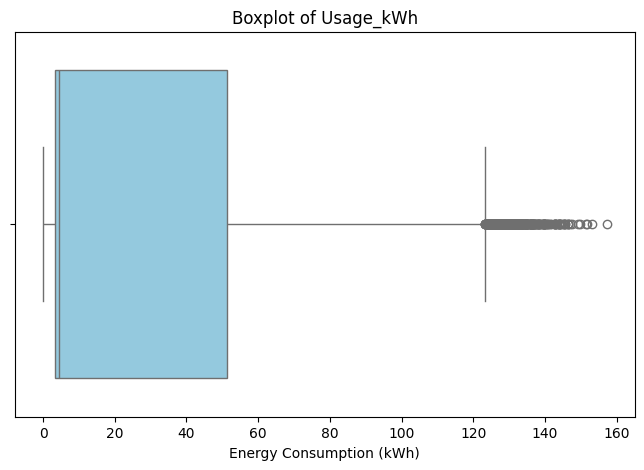

In [9]:
# STEP 5 : Detect Outliers using IQR Method


# Calculate Q1 (25th Percentile)
Q1 = df['Usage_kWh'].quantile(0.25)

# Calculate Q3 (75th Percentile)
Q3 = df['Usage_kWh'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate lower and upper limits
lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)

# Detect Outliers
outliers = df[
    (df['Usage_kWh'] < lower_limit) |
    (df['Usage_kWh'] > upper_limit)
]

# Print results
print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)

print("\nLower Limit :", lower_limit)
print("Upper Limit :", upper_limit)

print("\nNumber of Outliers :", len(outliers))

# Display first few outliers
print("\nFirst Five Outliers:")
print(outliers.head())


# Visualize Outliers using Boxplot


plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Usage_kWh'],
    color='skyblue'
)

plt.title("Boxplot of Usage_kWh")
plt.xlabel("Energy Consumption (kWh)")

plt.show()

# Step 6 — Correlation Heatmap & Top 3 Correlated Features

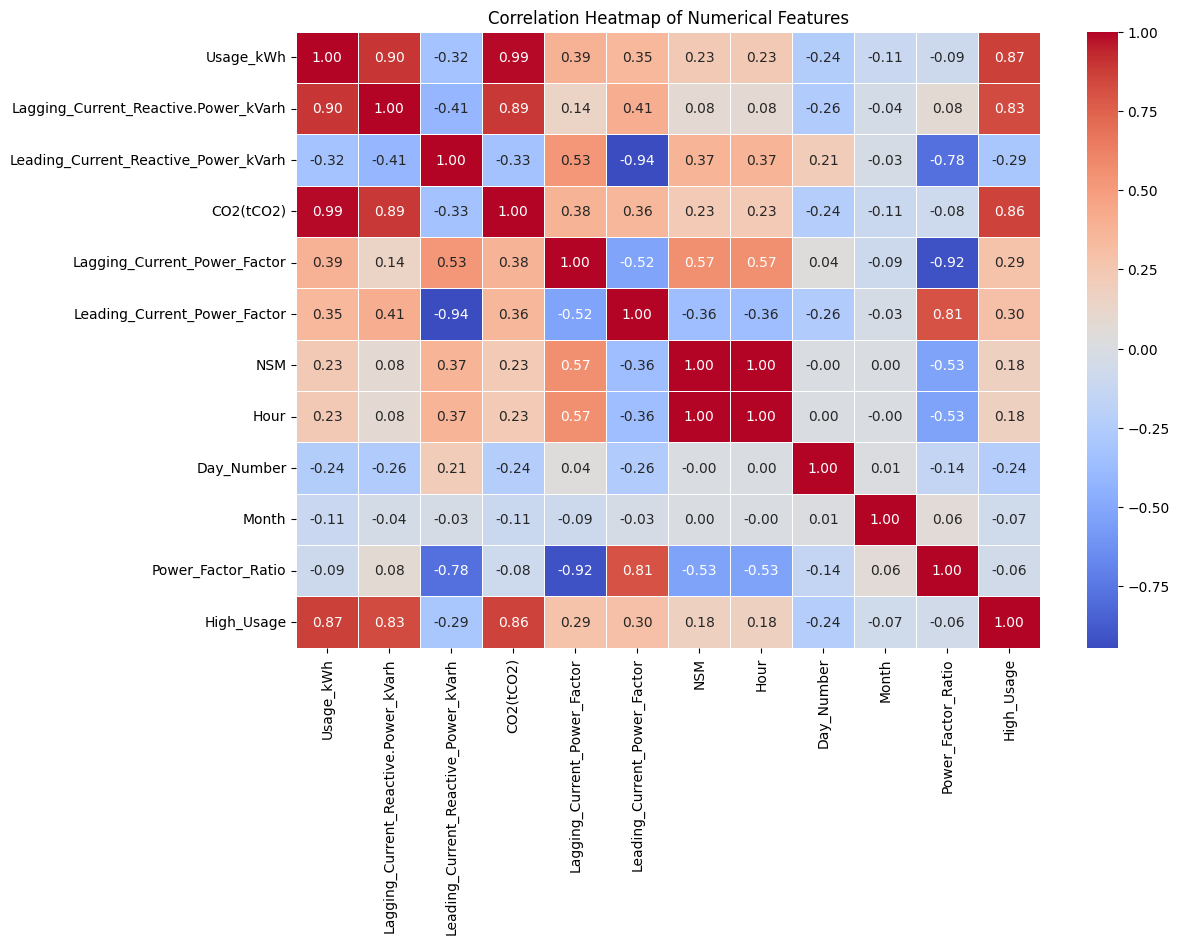

Top 3 Features Most Correlated with Usage_kWh:

CO2(tCO2)                               0.98818
Lagging_Current_Reactive.Power_kVarh    0.89615
High_Usage                              0.86784
Name: Usage_kWh, dtype: float64


In [10]:
# STEP 6 : Correlation Heatmap


# Select only numerical columns
numeric_df = df.select_dtypes(include=['number'])

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Create Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,          # Display correlation values
    cmap='coolwarm',     # Color theme
    fmt=".2f",           # Show 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()



# Top 3 Features Correlated with Usage_kWh


# Correlation of all features with Usage_kWh
usage_corr = correlation_matrix['Usage_kWh']

# Remove Usage_kWh itself
usage_corr = usage_corr.drop('Usage_kWh')

# Sort by absolute correlation values
top3 = usage_corr.abs().sort_values(ascending=False).head(3)

print("Top 3 Features Most Correlated with Usage_kWh:\n")
print(top3)

# Step 7 — Grouped Bar Chart of Average Energy Consumption by Load Type

Average Energy Consumption by Load Type:

      Load_Type  Usage_kWh
0    Light_Load   8.626207
1  Maximum_Load  59.265314
2   Medium_Load  38.445394


C:\Users\PMLS\AppData\Local\Temp\ipykernel_2540\4271763919.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


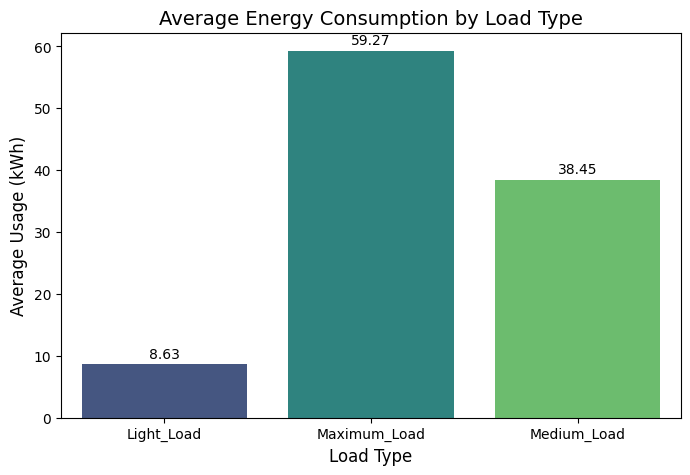

In [ ]:
# STEP 7 : Average Energy Consumption by Load Type


# Calculate average Usage_kWh for each Load Type
average_usage = df.groupby('Load_Type')['Usage_kWh'].mean().reset_index()

# Display the calculated averages
print("Average Energy Consumption by Load Type:\n")
print(average_usage)

# Create bar chart
plt.figure(figsize=(8,5))

sns.barplot(
    data=average_usage,
    x='Load_Type',
    y='Usage_kWh',
    palette='viridis'
)

# Add chart title and labels
plt.title("Average Energy Consumption by Load Type", fontsize=14)
plt.xlabel("Load Type", fontsize=12)
plt.ylabel("Average Usage (kWh)", fontsize=12)

# Display the average values on top of each bar
for index, value in enumerate(average_usage['Usage_kWh']):
    plt.text(index, value + 1, f"{value:.2f}",
             ha='center', fontsize=10)

plt.show()

# Step 8 — Line Chart of Average Energy Usage by Hour of Day

Average Energy Usage by Hour:
    Hour  Usage_kWh
0      0   7.870075
1      1   6.072479
2      2   4.428390
3      3   4.358041
4      4   4.309438
5      5   4.245548
6      6   4.223705
7      7   4.502075
8      8  37.704795
9      9  58.551733
10    10  55.874733
11    11  57.097459
12    12  18.461000
13    13  39.019500
14    14  56.155260
15    15  55.637541
16    16  55.799582
17    17  43.833096
18    18  33.020932
19    19  38.208514
20    20  37.477226
21    21  13.777363
22    22   8.658918
23    23   7.998014


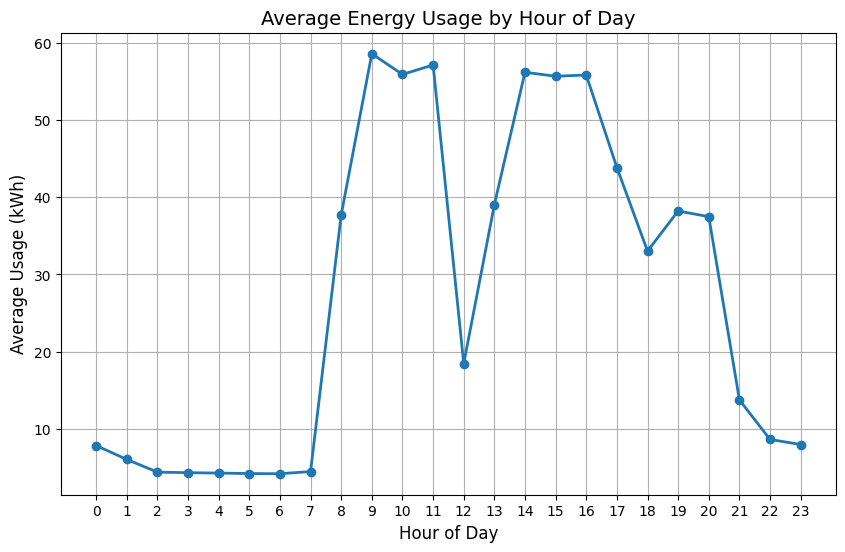

In [12]:
# STEP 8 : Average Energy Usage by Hour of Day


# Calculate average energy consumption for each hour
hourly_usage = df.groupby('Hour')['Usage_kWh'].mean().reset_index()

# Display the results
print("Average Energy Usage by Hour:")
print(hourly_usage)

# Create line chart
plt.figure(figsize=(10,6))

plt.plot(
    hourly_usage['Hour'],
    hourly_usage['Usage_kWh'],
    marker='o',
    linewidth=2
)

# Add chart title and labels
plt.title("Average Energy Usage by Hour of Day", fontsize=14)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Average Usage (kWh)", fontsize=12)

# Display all 24 hours on x-axis
plt.xticks(range(0, 24))

# Add grid for better readability
plt.grid(True)

# Show the chart
plt.show()

# **Step 9 — EDA Summary**

## Exploratory Data Analysis (EDA) Summary

The Steel Industry Energy Consumption dataset was explored to understand its structure, quality, and the factors influencing energy usage. During the initial analysis, the dataset was checked for missing values, duplicate records, and incorrect data types. The date column was successfully converted into a datetime format, allowing the extraction of useful time-based features such as hour of the day, day of the week, month, and weekday/weekend indicators. These engineered features provide additional information that can improve machine learning model performance.

A new feature, **Power_Factor_Ratio**, was created by dividing the leading current power factor by the lagging current power factor. Another feature, **High_Usage**, was generated using the 75th percentile of energy consumption to identify periods of unusually high electricity usage. Outlier detection using the IQR method revealed several extreme values in the **Usage_kWh** column. These outliers most likely represent periods of peak industrial activity rather than data entry errors and should be carefully considered before model training.

The correlation analysis showed that **Lagging_Current_Reactive.Power_kVarh**, **CO2(tCO2)**, and **Lagging_Current_Power_Factor** were among the features most strongly correlated with **Usage_kWh**, indicating that these variables have a significant influence on energy consumption. The grouped bar chart demonstrated that **Maximum Load** periods consume considerably more energy than **Medium Load** and **Light Load** periods. Furthermore, the hourly line chart revealed noticeable variations in energy consumption throughout the day, with higher usage occurring during active production hours.

Based on these findings, it can be hypothesized that energy spikes are primarily driven by increased production demand, heavier machine operation, and maximum load conditions during specific working hours. Overall, the dataset is well-structured and provides strong predictive features for developing accurate energy consumption regression models.
